<a href="https://colab.research.google.com/github/Sahdam/-Codeveda_Intership_Projects/blob/main/iris_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [3]:
url = "https://raw.githubusercontent.com/Sahdam/-Codeveda_Intership_Projects/refs/heads/main/Datasets/1)%20iris.csv"

iris_df = pd.read_csv(url)

In [4]:
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
print("The Dataset shape:",iris_df.shape)

print("\n")

print(iris_df.dtypes)

print("\n")

print(iris_df.info())

print("\n")

print(round(iris_df.describe(), 2))

The Dataset shape: (150, 5)


sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


       sepal_length  sepal_width  petal_length  petal_width
count        150.00       150.00        150.00       150.00
mean           5.84         3.05          3.76         1.20
std            0.83         0.43          1.76         0.76
min            4.30         2.00          1.00         0.10
25%            5.10         2.80          1.60         0.30
50%       

In [6]:
print(iris_df.duplicated().sum())

print('\n')

print(iris_df.isnull().sum())

print('\n')

print(iris_df['species'].value_counts())

3


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [7]:
iris_df = iris_df.drop_duplicates().reset_index(drop=True)

In [8]:
iris_df.duplicated().sum()

np.int64(0)

In [9]:
iris_df['species'].value_counts()

,count
species,
versicolor,50
virginica,49
setosa,48


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

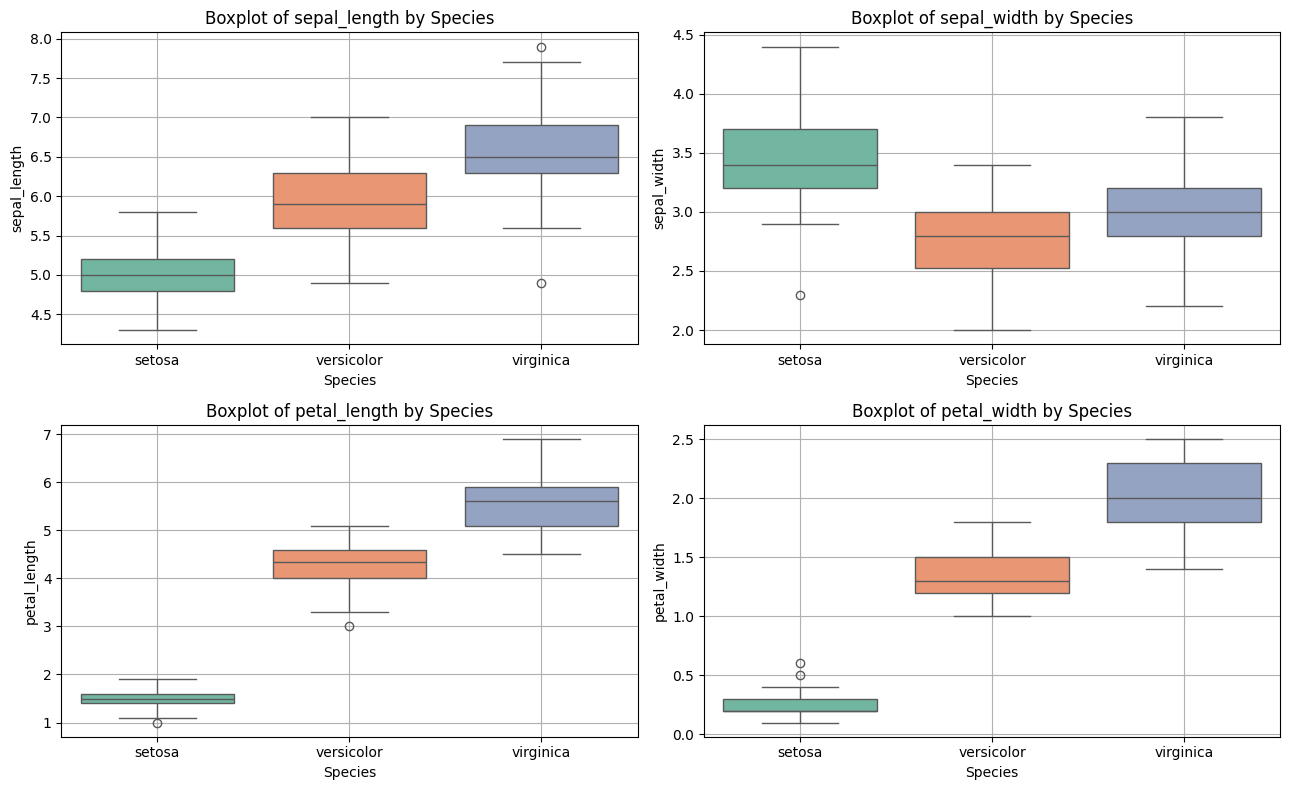

In [11]:
fig, ax = plt.subplots(2,2, figsize=(13, 8))

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for ax, feat in zip(ax.flatten(), features):
    sns.boxplot(data=iris_df, x='species', y=feat, hue='species', ax=ax, palette='Set2')
    ax.set_title(f'Boxplot of {feat} by Species')
    ax.set_xlabel('Species')
    ax.set_ylabel(feat)
    ax.grid(True)

plt.tight_layout()
plt.show()

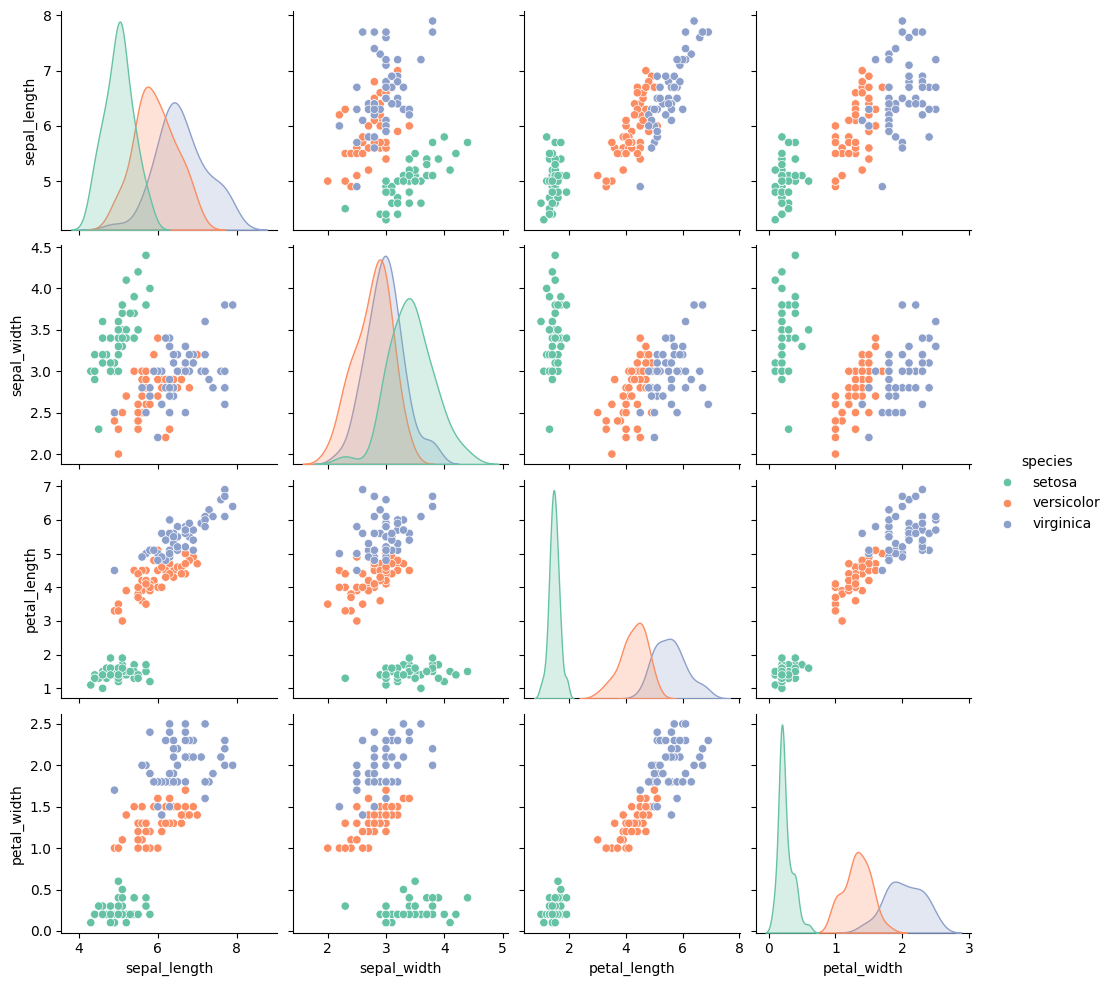

In [12]:
sns.pairplot(iris_df, hue='species', palette='Set2')
plt.show()

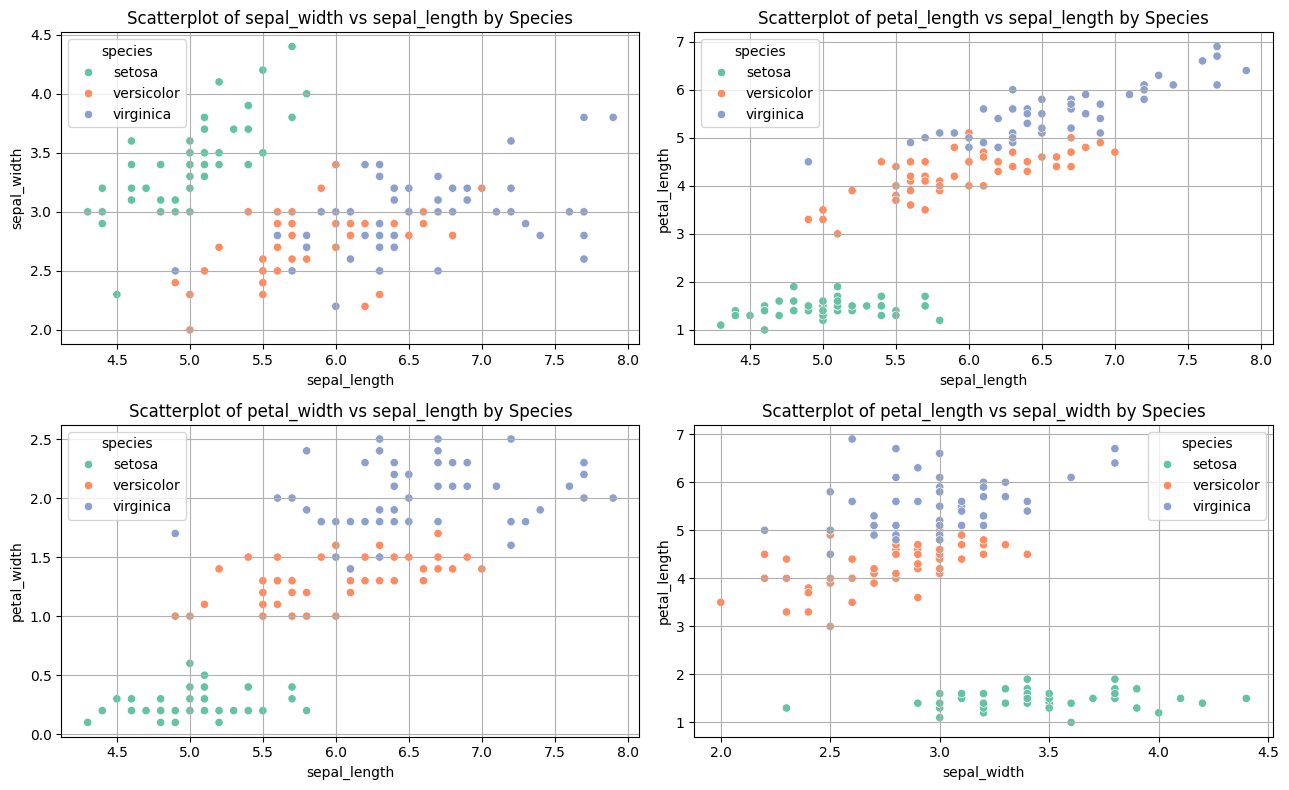

In [13]:
fig, ax = plt.subplots(2,2, figsize=(13, 8))

plot_pairs = [
    ('sepal_length', 'sepal_width'),
    ('sepal_length', 'petal_length'),
    ('sepal_length', 'petal_width'),
    ('sepal_width', 'petal_length')
]

for i, ax_single in enumerate(ax.flatten()):
    if i < len(plot_pairs):
        x_feat, y_feat = plot_pairs[i]
        sns.scatterplot(data=iris_df, x=x_feat, y=y_feat, hue='species', ax=ax_single, palette='Set2')
        ax_single.set_title(f'Scatterplot of {y_feat} vs {x_feat} by Species')
        ax_single.set_xlabel(x_feat)
        ax_single.set_ylabel(y_feat)
        ax_single.grid(True)
    else:
        ax_single.set_visible(False)

plt.tight_layout()
plt.show()

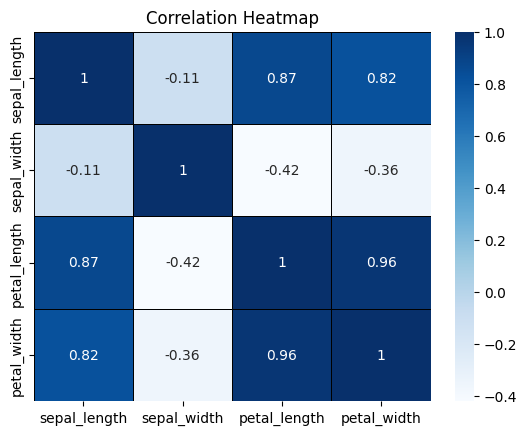

In [14]:
corr_matrix = iris_df.select_dtypes('number').corr()

sns.heatmap(corr_matrix, annot=True, cmap='Blues', linewidths=0.5, linecolor='black')
plt.title('Correlation Heatmap')
plt.show()

In [15]:
iris_df['petal_ratio'] = iris_df['petal_length'] / iris_df['petal_width']
iris_df['sepal_ratio'] = iris_df['sepal_length'] / iris_df['sepal_width']
iris_df['petal_area'] = iris_df['petal_length'] * iris_df['petal_width']
iris_df['sepal_area'] = iris_df['sepal_length'] * iris_df['sepal_width']
iris_df['petal_perimeter'] = 2 * (iris_df['petal_length'] + iris_df['petal_width'])
iris_df['petal_sepal_ratio'] = iris_df['petal_length'] / iris_df['sepal_length']

In [16]:
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,petal_ratio,sepal_ratio,petal_area,sepal_area,petal_perimeter,petal_sepal_ratio
0,5.1,3.5,1.4,0.2,setosa,7.0,1.457143,0.28,17.85,3.2,0.274510
1,4.9,3.0,1.4,0.2,setosa,7.0,1.633333,0.28,14.70,3.2,0.285714
2,4.7,3.2,1.3,0.2,setosa,6.5,1.468750,0.26,15.04,3.0,0.276596
3,4.6,3.1,1.5,0.2,setosa,7.5,1.483871,0.30,14.26,3.4,0.326087
4,5.0,3.6,1.4,0.2,setosa,7.0,1.388889,0.28,18.00,3.2,0.280000


In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [18]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(iris_df.select_dtypes('number'))

In [19]:
pca = PCA(n_components=4)
pca.fit(scaled_data)

PCA(n_components=4)

In [20]:
explained_var_ratio = pca.explained_variance_ratio_
cumulative_var_ratio = np.cumsum(explained_var_ratio)

In [21]:
print("Explained Variance Ratio:", explained_var_ratio)
print("Cumulative Explained Variance Ratio:", cumulative_var_ratio)

Explained Variance Ratio: [0.71590413 0.1964232  0.04830671 0.03064961]
Cumulative Explained Variance Ratio: [0.71590413 0.91232733 0.96063404 0.99128365]


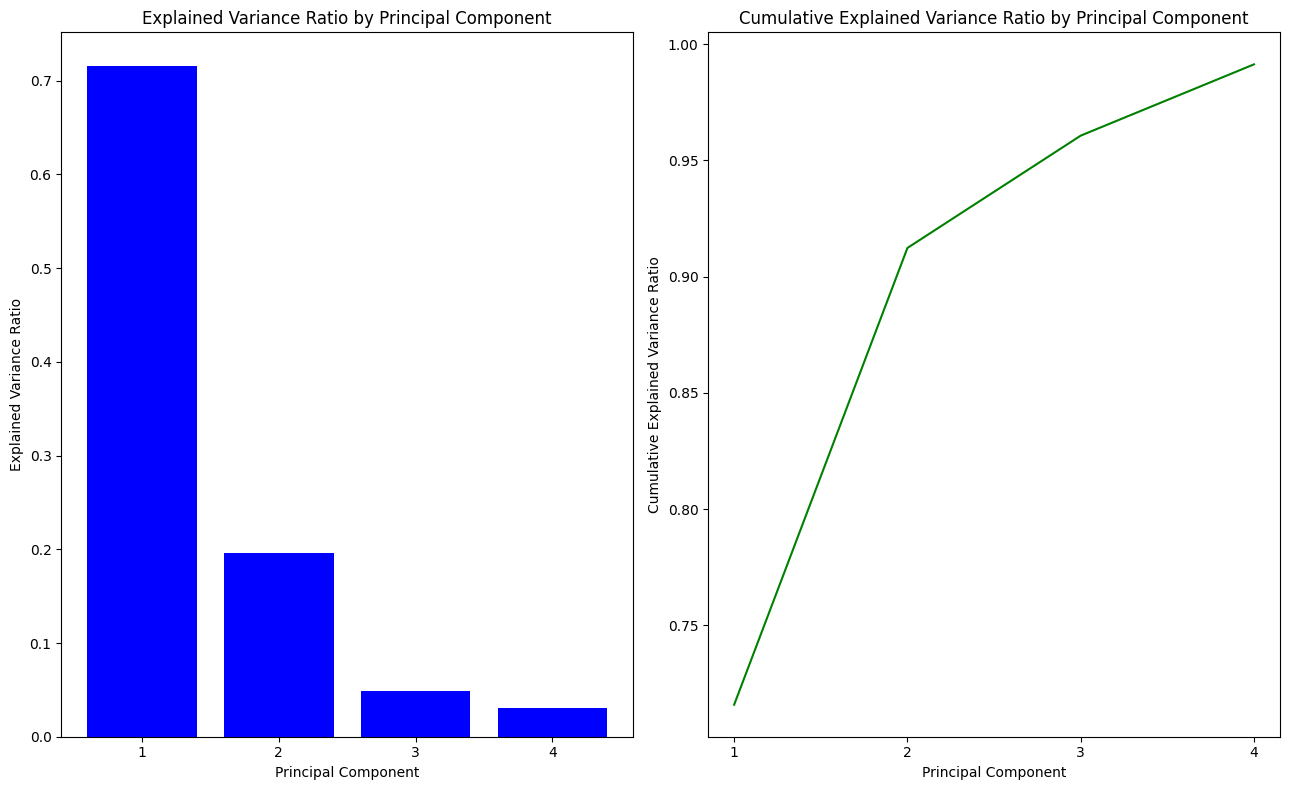

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 8))

ax[0].bar(range(1, 5), explained_var_ratio, color='blue')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Explained Variance Ratio')
ax[0].set_title('Explained Variance Ratio by Principal Component')
ax[0].set_xticks(range(1, 5))

ax[1].plot(range(1, 5), cumulative_var_ratio, color='green')
ax[1].set_xlabel('Principal Component')
ax[1].set_ylabel('Cumulative Explained Variance Ratio')
ax[1].set_title('Cumulative Explained Variance Ratio by Principal Component')
ax[1].set_xticks(range(1, 5))

plt.tight_layout()
plt.show()


In [23]:
pca2 = PCA(n_components=2, random_state=42)
pca_result = pca2.fit_transform(scaled_data)

print(f'pca_result shape: {pca_result.shape}')
print(f'var explained: {pca2.explained_variance_ratio_.sum():.2f}')

pca_result shape: (147, 2)
var explained: 0.91


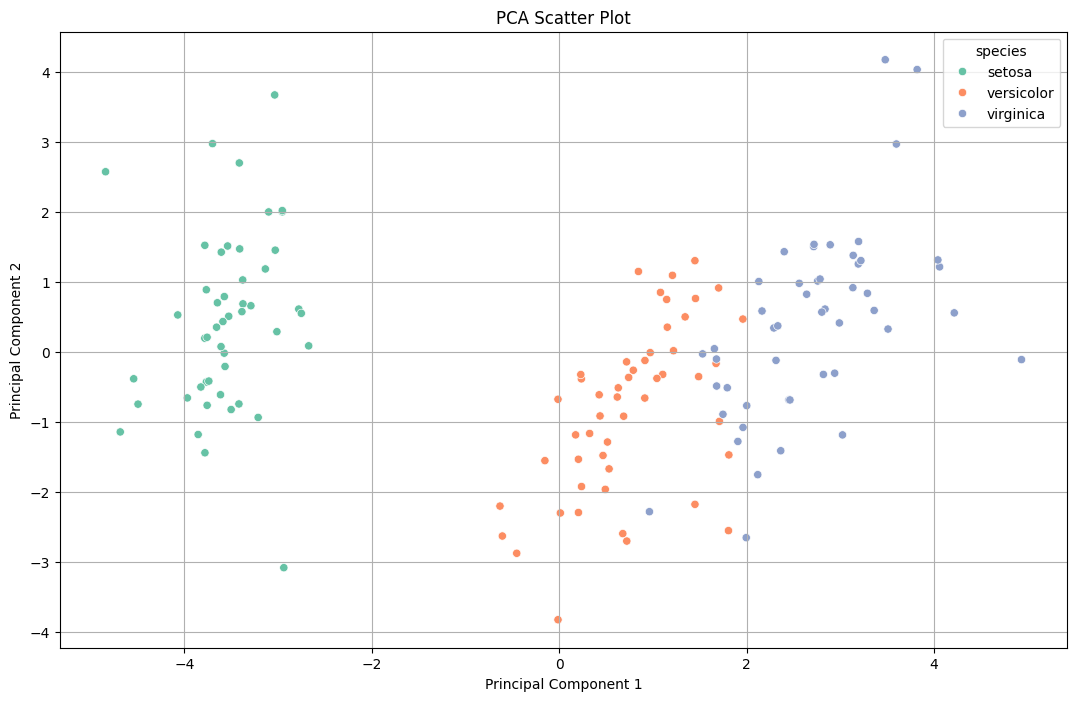

In [24]:
fig, ax = plt.subplots(figsize=(13, 8))

sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=iris_df['species'], palette='Set2', ax=ax)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('PCA Scatter Plot')
ax.grid(True)

plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder

In [26]:
le = LabelEncoder()

iris_df['target'] = le.fit_transform(iris_df['species'])

In [27]:
print(iris_df[['species', 'target']].drop_duplicates())

       species  target
0       setosa       0
48  versicolor       1
98   virginica       2


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [29]:
X = iris_df.drop(['species', 'target'], axis=1)
y = iris_df['target']

In [30]:
X.shape, y.shape

((147, 10), (147,))

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
X_train.shape, y_train.shape

((117, 10), (117,))

In [33]:
X_test.shape, y_test.shape

((30, 10), (30,))

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [35]:
models = {
    'Logistic Regression': LogisticRegression(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC(),
    'Naive Bayes': GaussianNB()
}

In [36]:
for model_name, model in models.items():
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    print(f'{model_name}  test accuracy:  {accuracy:.2f}')

Logistic Regression  test accuracy:  1.00
K-Nearest Neighbors  test accuracy:  1.00
Decision Tree  test accuracy:  0.90
Random Forest  test accuracy:  0.97
Support Vector Machine  test accuracy:  1.00
Naive Bayes  test accuracy:  0.97


In [37]:
from sklearn.metrics import confusion_matrix, classification_report

In [38]:
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    clr = classification_report(y_test, y_pred, target_names=iris_df['species'].unique())
    print(f'{model_name}  classification report:\n{clr}')

Logistic Regression  classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

K-Nearest Neighbors  classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Decision Tree  classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  v

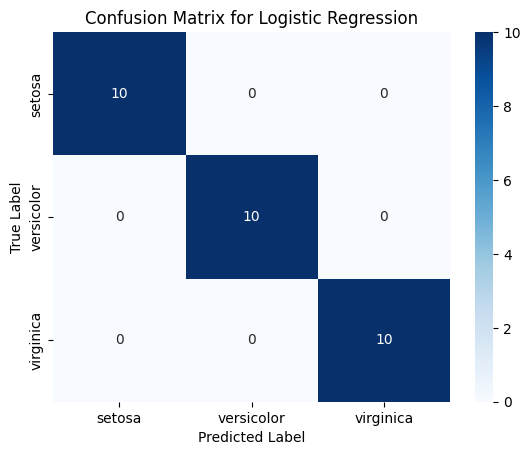

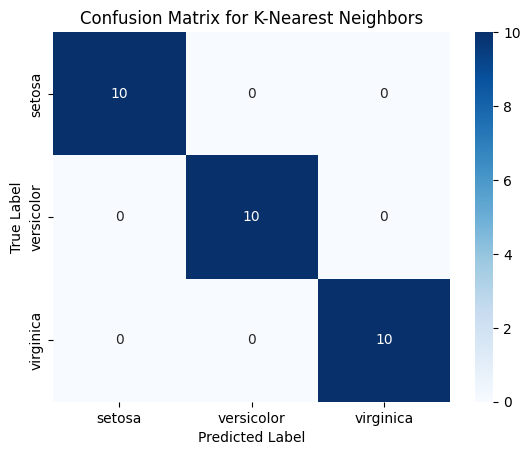

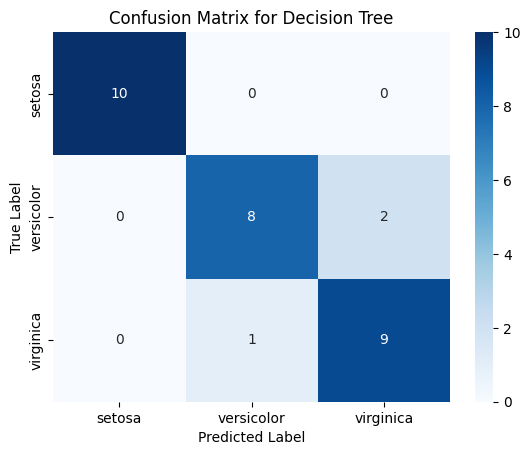

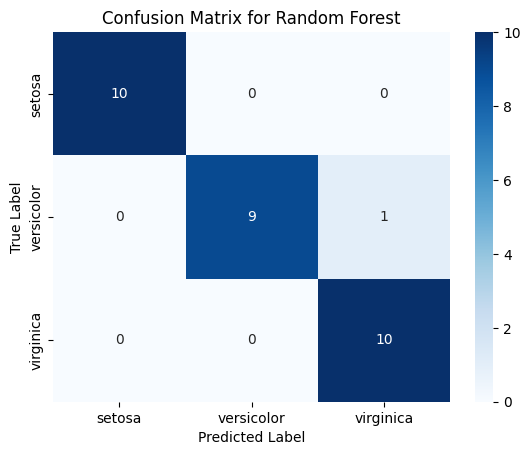

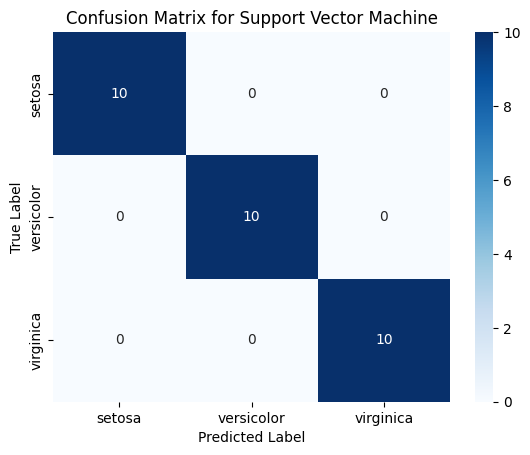

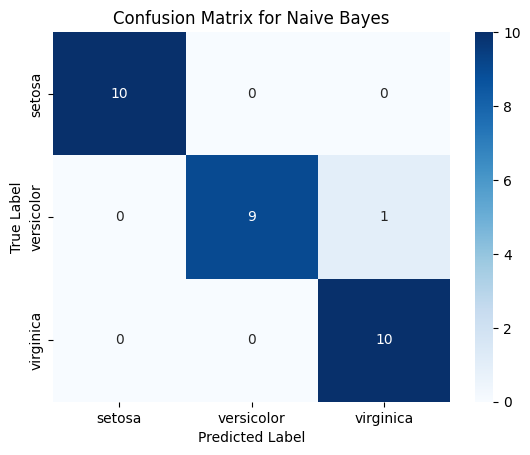

In [39]:
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris_df['species'].unique(), yticklabels=iris_df['species'].unique())
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [40]:
from sklearn.model_selection import cross_val_score

In [41]:
print(f"{'Model':22s}  {'Mean':>6}  {'Std':>6}  {'Min':>6}")
print("-" * 48)
for model_name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f'{model_name:22s} {cv_scores.mean():.3f}   {cv_scores.std():.3f}   {cv_scores.min():.3f}')

Model                     Mean     Std     Min
------------------------------------------------
Logistic Regression    0.972   0.034   0.931
K-Nearest Neighbors    0.973   0.014   0.966
Decision Tree          0.945   0.035   0.897
Random Forest          0.966   0.022   0.931
Support Vector Machine 0.966   0.022   0.931
Naive Bayes            0.959   0.026   0.931


In [42]:
import joblib

joblib.dump(models['Support Vector Machine'], 'iris_model.pkl')

['iris_model.pkl']

In [43]:
# train.py
import joblib
import pandas as pd
from sklearn.datasets        import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.pipeline        import Pipeline
from sklearn.svm             import SVC

url = "https://raw.githubusercontent.com/Sahdam/-Codeveda_Intership_Projects/refs/heads/main/Datasets/1)%20iris.csv"

df = pd.read_csv(url)
df = df.drop_duplicates().reset_index(drop=True)

X = df[['sepal_length','sepal_width','petal_length','petal_width']].values
y = LabelEncoder().fit_transform(df['species'])   # 0=setosa,1=versicolor,2=virginica

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

pipe = Pipeline([('sc', StandardScaler()),
                 ('clf', SVC(probability=True, random_state=42))])

grid = GridSearchCV(pipe,
    {'clf__C':[1,10], 'clf__gamma':[0.1,'scale'], 'clf__kernel':['rbf']},
    cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best CV acc : {grid.best_score_:.4f}")
print(f"Test acc    : {grid.best_estimator_.score(X_test, y_test):.4f}")

joblib.dump(grid.best_estimator_, 'iris_model_v1.pkl')
print("Saved → iris_model_v1.pkl")

Best CV acc : 0.9583
Test acc    : 0.9667
Saved → iris_model_v1.pkl
